In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#### Inspect Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# __ Convert Churn to int data type
# __Convert TotalCharges to float data

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No' : 0
}).astype(int)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#__ coerce return NAN as the errors
#__ fill the NAN in the TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [7]:
#__ Data type fix for both Churn and TotalCharges columns and no MV
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#__Check duplicate values
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.describe().round(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000,7043.000,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762,2281.917,0.265
std,0.369,24.559,30.090,2265.270,0.442
min,0.000,0.000,18.250,18.800,0.000
25%,0.000,9.000,35.500,402.225,0.000
50%,0.000,29.000,70.350,1397.475,0.000
75%,0.000,55.000,89.850,3786.600,1.000
max,1.000,72.000,118.750,8684.800,1.000


In [11]:
df.describe(include='O') #__ No high cardinalities in the columns

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


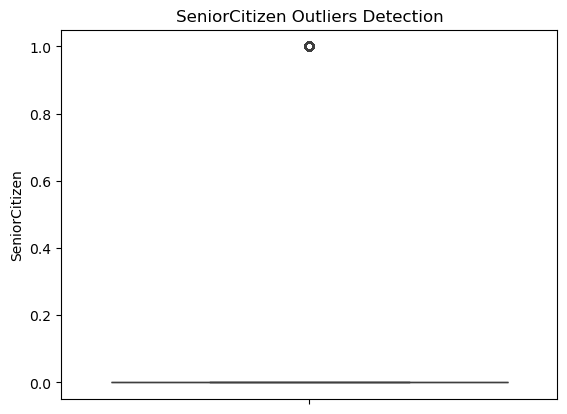

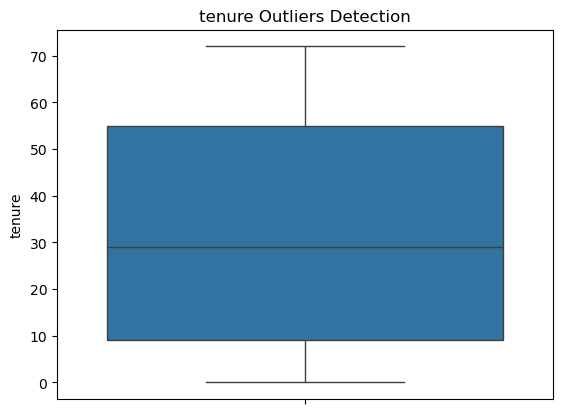

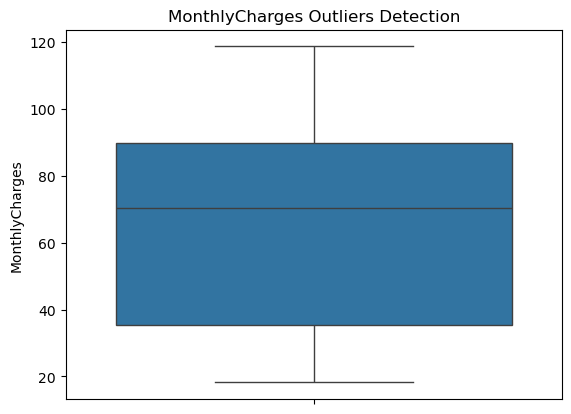

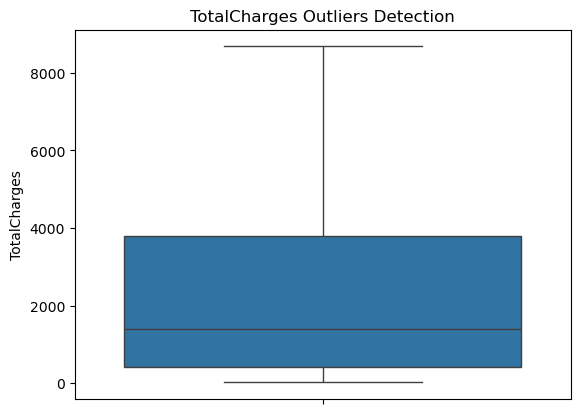

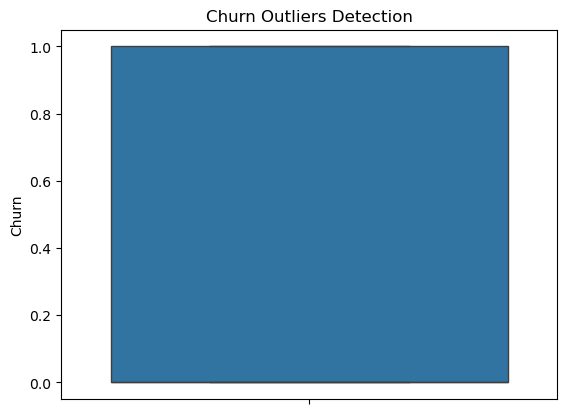

In [12]:
## _Detect possible outliers
for col in df.select_dtypes('number').columns:
    sns.boxplot(df[col])
    plt.title(f"{col} Outliers Detection")
    plt.show();

### Exploratory Data Analysis

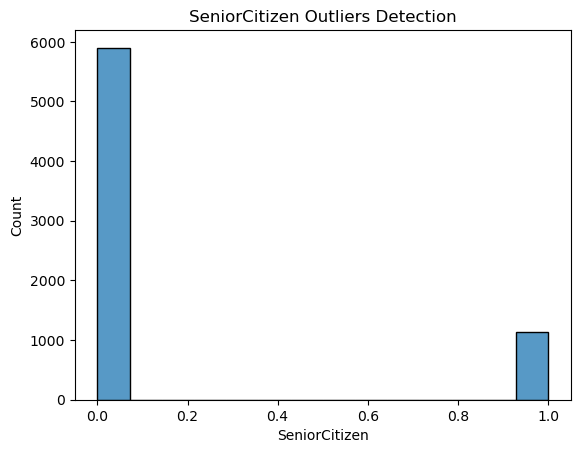

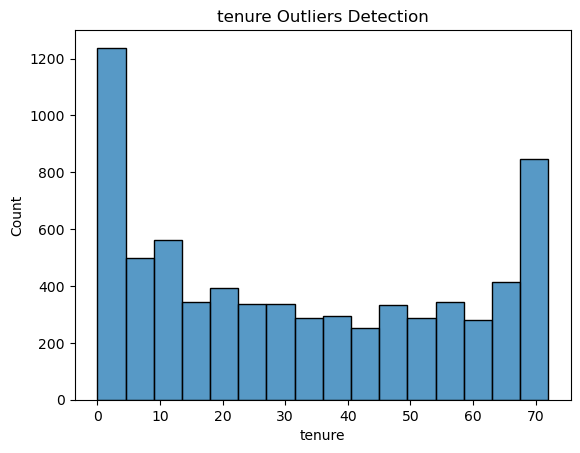

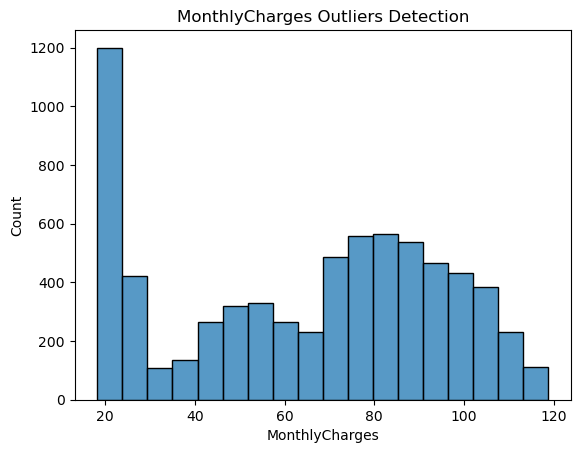

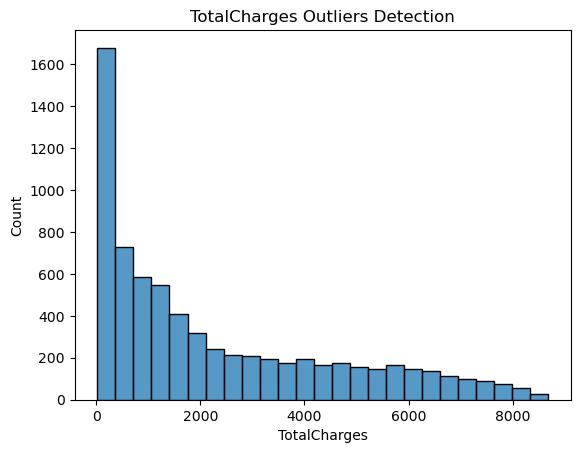

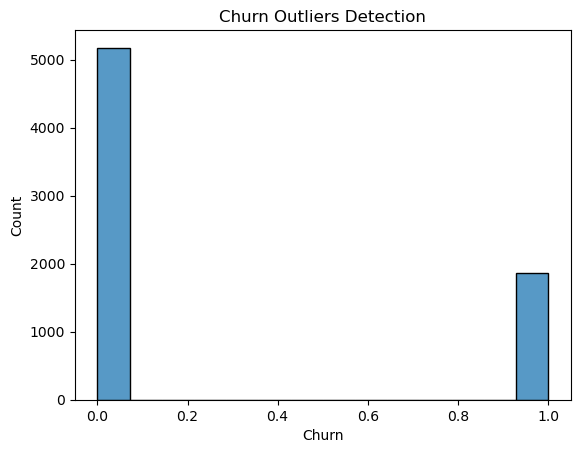

In [14]:
for col in df.select_dtypes('number').columns:
    sns.histplot(df[col])
    plt.title(f"{col} Outliers Detection")
    plt.show();

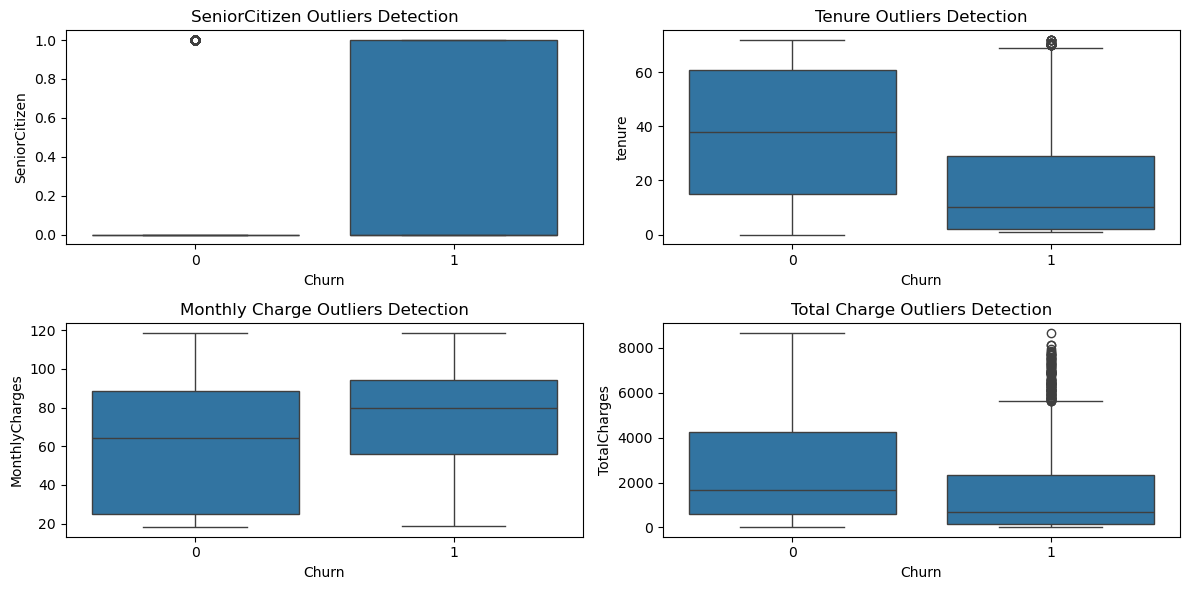

In [15]:
fig, ax = plt.subplots(2, 2,figsize=(12, 6))
sns.boxplot(df , y='SeniorCitizen', x='Churn', ax=ax[0,0])
ax[0, 0].set_title("SeniorCitizen Outliers Detection")
sns.boxplot(df , y='tenure', x='Churn', ax=ax[0,1])
ax[0, 1].set_title("Tenure Outliers Detection")
sns.boxplot(df , y='MonthlyCharges', x='Churn', ax=ax[1,0])
ax[1, 0].set_title("Monthly Charge Outliers Detection")
sns.boxplot(df , y='TotalCharges', x='Churn', ax=ax[1,1])
ax[1, 1].set_title("Total Charge Outliers Detection")
plt.tight_layout()
plt.show()

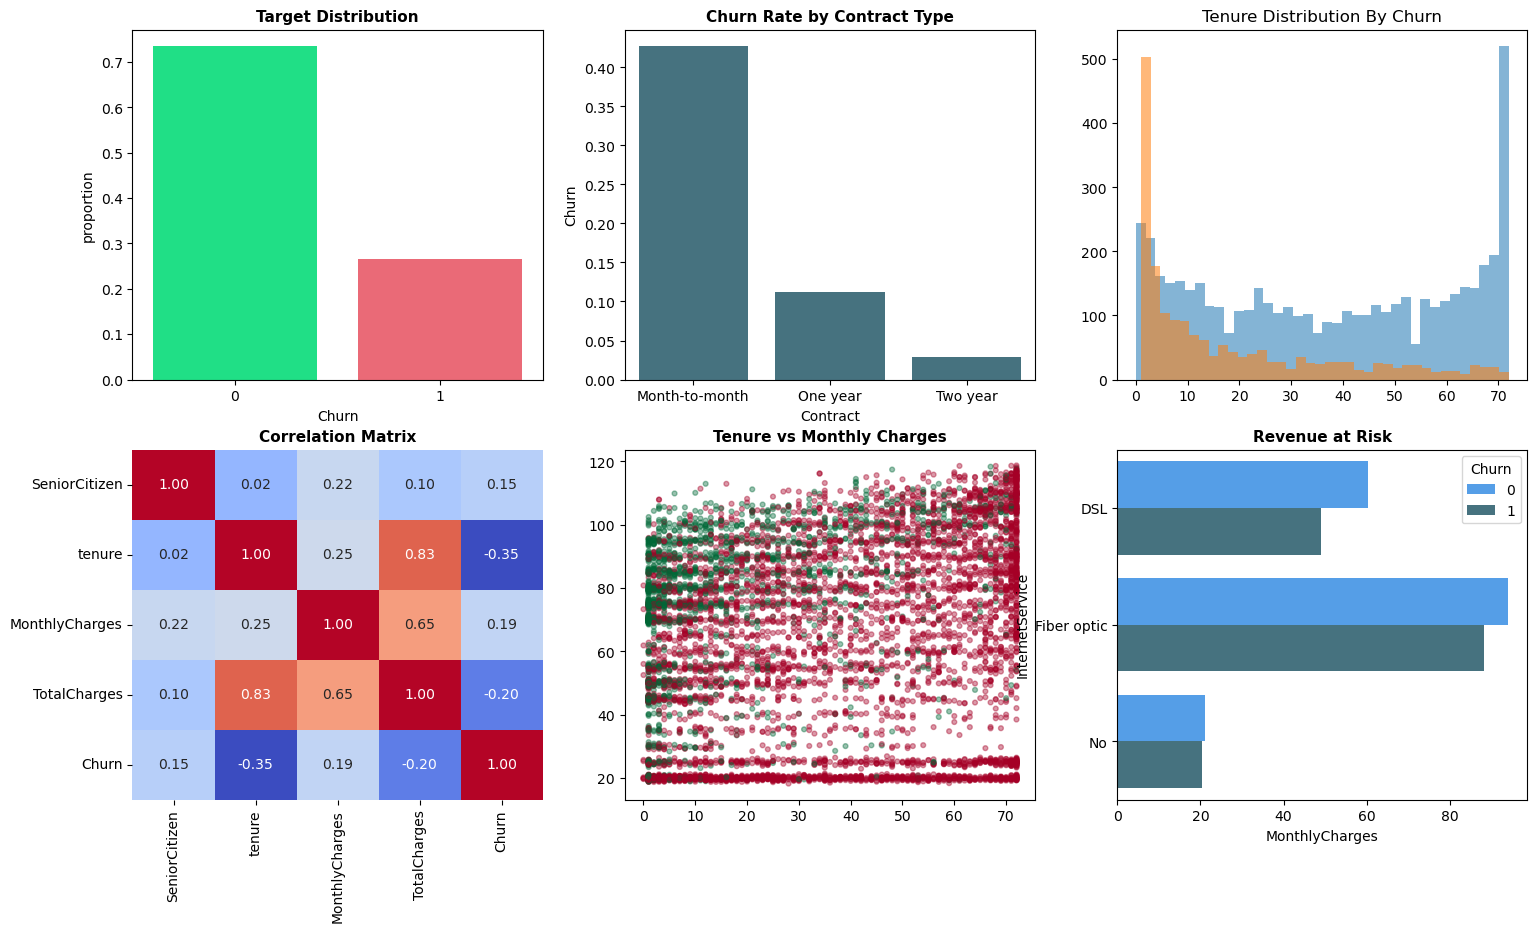

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
sns.barplot(df['Churn'].value_counts(normalize=True), errorbar=None,
           palette=["#00ff88", "#ff5566"], ax=ax[0,0])
ax[0, 0].set_title("Target Distribution",fontsize=11, fontweight='bold')
sns.barplot(df.groupby("Contract")['Churn']
            .mean().sort_values(ascending=False),
           ax = ax[0, 1], color="#3d7788")
ax[0,1].set_title("Churn Rate by Contract Type",fontsize=11, fontweight='bold')
for label, grp in df.groupby('Churn'):
    ax[0, 2].hist(grp['tenure'], alpha=0.55,label=f"Churn={label}", bins=38)
    ax[0,2].set_title("Tenure Distribution By Churn")
ax[1,1].scatter(df['tenure'], df['MonthlyCharges'],
               c=df['Churn'], cmap="RdYlGn",alpha=0.4, s=12)
ax[1,1].set_title("Tenure vs Monthly Charges", fontsize=11, fontweight='bold')
num_col = df.select_dtypes("number").columns
sns.heatmap(df[num_col].corr(), fmt='.2f', cmap='coolwarm', cbar=False, annot=True,
           ax=ax[1, 0])
ax[1, 0].set_title("Correlation Matrix", fontsize=11, fontweight='bold')
sns.barplot(df, x='MonthlyCharges', y='InternetService', hue='Churn',orient='h',
            errorbar=None, palette=['#3d9eff',"#3d7788"],ax= ax[1, 2])
ax[1,2].set_title("Revenue at Risk",fontsize=11, fontweight='bold')
plt.show()

### Preprocessing

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [19]:
cat_col = ['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod']
num_col =['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [20]:
X = df[cat_col + num_col]
y = df['Churn']

X_temp, X_test, y_temp, y_test = train_test_split(
    X,y, test_size= 0.15,
    random_state = 42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.18,
    random_state=42,stratify=y_temp
)

In [49]:
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(
        handle_unknown='ignore', sparse_output=False, drop='first'
    ))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_col),
    ('cat', cat_pipe, cat_col)
], remainder='passthrough',verbose_feature_names_out=False)

print(f"Numerical pipeline ✅ \n{num_pipe}")
print(f"Categorical pipeline ✅ \n{cat_pipe}")
print(f"Preprocessor ✅ \n{preprocessor}")

Numerical pipeline ✅ 
Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])
Categorical pipeline ✅ 
Pipeline(steps=[('impute', SimpleImputer(strategy='most_frequent')),
                ('encode',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])
Preprocessor ✅ 
ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges', 'charge_per_tenure',
                                  'ServiceCount', 'charge_cohort',
                                  'Is_new_customer', 'High_Value_New']),
         

In [51]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Feature Engineering

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin

In [25]:
class churnfeatureengineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        #learn Cohort averages only from training data
        self.cohort_avg_ = (
            X.groupby(['Contract','InternetService'])
            ['MonthlyCharges'].mean().round(3)
        )
        return self

    def transform(self, X):
        X = X.copy()
        
        #cost efficiency ratio tenure
        X['charge_per_tenure'] = (
            X["TotalCharges"] / (X["tenure"] + 1)
        )
    
        #Number of active services
        svc_col = ['PhoneService', 'OnlineSecurity','TechSupport',
                  'StreamingTV']
        X['ServiceCount'] = (X[svc_col] !='No').sum(axis=1)
    
        peer_avg = X.apply(
            lambda r: self.cohort_avg_.get(
                (r['Contract'], r['InternetService']), 0
            ), axis=1
        )
    
        X["charge_cohort"] = X['MonthlyCharges'] - peer_avg
    
        #New customer flag (first 6 month = high-risk-window)
        X["Is_new_customer"] = (X["tenure"] <= 6).astype(int)
    
        X["High_Value_New"] = (
            (X['Is_new_customer']==1) &
            (X['MonthlyCharges'] > 70)
        ).astype(int)

        return X

In [47]:
num_col = num_col + ['charge_per_tenure',
                    'ServiceCount','charge_cohort','Is_new_customer',
                    'High_Value_New']
num_col

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'charge_per_tenure',
 'ServiceCount',
 'charge_cohort',
 'Is_new_customer',
 'High_Value_New']

In [53]:
#Full pipeline after feature engineer
full_pipeline = Pipeline([
    ('feature_engineer', churnfeatureengineer()),
    ('preprocess', preprocessor)
])
full_pipeline

,steps,"[('feature_engineer', ...), ('preprocess', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [55]:
print(full_pipeline)

Pipeline(steps=[('feature_engineer', churnfeatureengineer()),
                ('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'charge_per_tenure',
                                                   'ServiceCount',
                                                   'charge_cohort',
                         

### Feature Selection

In [58]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest, RFE

In [60]:
X_proc = full_pipeline.fit_transform(X_train)
feat_name = preprocessor.get_feature_names_out()

mi = mutual_info_classif(
    X_proc, y_train, random_state=42
)

mi_series = pd.Series(mi, index=feat_name).sort_values(ascending=False)
mi_series.head(10)

tenure                                 0.069810
ServiceCount                           0.064890
Contract_Two year                      0.062637
PaymentMethod_Electronic check         0.055994
InternetService_Fiber optic            0.049686
Is_new_customer                        0.046791
MonthlyCharges                         0.043843
StreamingMovies_No internet service    0.042262
TotalCharges                           0.042019
charge_cohort                          0.040211
dtype: float64

In [61]:
mi_series

tenure                                   0.069810
ServiceCount                             0.064890
Contract_Two year                        0.062637
PaymentMethod_Electronic check           0.055994
InternetService_Fiber optic              0.049686
Is_new_customer                          0.046791
MonthlyCharges                           0.043843
StreamingMovies_No internet service      0.042262
TotalCharges                             0.042019
charge_cohort                            0.040211
charge_per_tenure                        0.038015
DeviceProtection_No internet service     0.034274
InternetService_No                       0.030790
High_Value_New                           0.030178
OnlineBackup_No internet service         0.029307
TechSupport_No internet service          0.025003
OnlineSecurity_No internet service       0.024428
Contract_One year                        0.024375
StreamingTV_No internet service          0.023987
PaperlessBilling_Yes                     0.022329


### Model Training

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import f1_score,confusion_matrix

In [66]:
spw = (y_train==0).sum() /(y_train==1).sum()

In [69]:
MODELS = {
    'Logistic (baseline)': Pipeline([
        ('pipe', full_pipeline),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced', C=0.1
        ))
    ]),
    'Random forest': Pipeline([
        ('pipe', full_pipeline),
        ('clf', RandomForestClassifier(
            class_weight='balanced',
            max_depth = 6,
            n_estimators=200, n_jobs=-1
        ))
    ]),
    'Gradient Boost': Pipeline([
        ('pipe', full_pipeline),
        ('clf',  GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4
        ))
    ]),
    'XGboost': Pipeline([
        ('pipe', full_pipeline),
        ('clf', XGBClassifier(
            scale_pos_weight=spw,
            learning_rate = 0.05, eval_metric='auc',
            subsample =0.8, max_depth=6,
            n_estimators=500, n_jobs=-1
        ))
    ]),
    'Lightgbm': Pipeline([
        ('pipe', full_pipeline),
        ('clf', LGBMClassifier(
            n_estimators=500, class_weight='balanced',
            learning_rate=0.05, verbose=-1
        ))
    ])
}

result = {}

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)
for name, pline in MODELS.items():
    scores = cross_val_score(
        pline, X_train, y_train,
        cv = cv, scoring = "roc_auc",
        n_jobs=-1
    )
    result[name] = scores
    print(f"{name:25s} AUC={scores.mean():.3f} ± {scores.std():.3f}")

Logistic (baseline)       AUC=0.849 ± 0.013
Random forest             AUC=0.847 ± 0.014
Gradient Boost            AUC=0.844 ± 0.012
XGboost                   AUC=0.833 ± 0.014
Lightgbm                  AUC=0.831 ± 0.015


### MODEL TUNING (XGB & GB)

In [71]:
from sklearn.model_selection import RandomizedSearchCV
param_gb = {
    "clf__n_estimators": [100, 300, 500],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__min_samples_leaf": [10, 30, 50],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__max_features": ["sqrt", "log2", None]
}

search_gb = RandomizedSearchCV(
    MODELS["Gradient Boost"],param_gb,
    n_iter=30,
    scoring="roc_auc", cv=cv,
    n_jobs=-1, random_state=42, verbose=1
)

search_gb.fit(X_train, y_train)
best_model_gb = search_gb.best_estimator_
print(f"Best CV AUC: {search_gb.best_score_:.4f}")
print(f"Best Params: {search_gb.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC: 0.8502
Best Params: {'clf__subsample': 0.6, 'clf__n_estimators': 300, 'clf__min_samples_leaf': 30, 'clf__max_features': 'sqrt', 'clf__learning_rate': 0.03}


In [97]:
search_gb.cv_results_['std_test_score'].mean()

0.012623796833748742

In [72]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    "clf__max_depth":        [3, 4, 5, 6, 7, 8],
    "clf__learning_rate":    [0.01, 0.05, 0.1, 0.15],
    "clf__n_estimators":     [300, 500, 700, 1000],
    "clf__subsample":        [0.6, 0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__gamma":            [0, 0.1, 0.5, 1],
    "clf__reg_alpha":        [0, 0.1, 0.5, 1],
    "clf__reg_lambda":       [1, 3, 5, 10],
    "clf__min_child_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    MODELS["XGboost"], param_dist,
    n_iter=80, scoring="roc_auc", cv=cv,
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Best Params: {search.best_params_}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best CV AUC: 0.8503
Best Params: {'clf__subsample': 0.6, 'clf__reg_lambda': 10, 'clf__reg_alpha': 1, 'clf__n_estimators': 1000, 'clf__min_child_weight': 1, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__gamma': 1, 'clf__colsample_bytree': 1.0}


### EVALUATION

In [145]:
from sklearn.metrics import (precision_score, recall_score, classification_report, accuracy_score,roc_auc_score)

y_proba_xg = best_model.predict_proba(X_test)[:, 1]
pred_test_xg =best_model.predict(X_test)
# Maximize expected business value across thresholds
thresholds = 0.4
ev_scores  = []

y_pred = (y_proba_xg >= 0.4).astype(int)
tp = ((y_pred==1) & (y_test==1)).sum()
fp = ((y_pred==1) & (y_test==0)).sum()
fn = ((y_pred==0) & (y_test==1)).sum()
ev = tp*180 + fp*(-15) + fn*(-200)
ev_scores.append(ev)


print(f"Correctly detected churners (TP): {tp}")
print(f"Wrongly targeted loyal customers: {fp}")
print(f"Missed churners: {fn}")

print(f"Classification Report: \n {classification_report(y_test, pred_test_xg,target_names=['Stay', 'Churn'])}")
print(f"Accuracy: {accuracy_score(y_test,pred_test_xg):.3f}")
print(f"AUC: {roc_auc_score(y_test,y_proba_xg):.3f}")
print(f"Precision: {precision_score(y_test,pred_test_xg):.3f}")
print(f"Recall: {recall_score(y_test,pred_test_xg):.3f}")
print(f"F1-Score: {f1_score(y_test,pred_test_xg):.3f}")

Correctly detected churners (TP): 245
Wrongly targeted loyal customers: 266
Missed churners: 35
Classification Report: 
               precision    recall  f1-score   support

        Stay       0.91      0.72      0.81       777
       Churn       0.51      0.81      0.63       280

    accuracy                           0.75      1057
   macro avg       0.71      0.77      0.72      1057
weighted avg       0.81      0.75      0.76      1057

Accuracy: 0.747
AUC: 0.856
Precision: 0.515
Recall: 0.811
F1-Score: 0.630


In [147]:
y_proba_gb = best_model_gb.predict_proba(X_test)[:, 1]
pred_test_gb =best_model_gb.predict(X_test)

print(f"Classification Report: \n {classification_report(y_test, pred_test_gb,target_names=['Stay', 'Churn'])}")
print(f"Accuracy: {accuracy_score(y_test,pred_test_gb):.3f}")
print(f"AUC: {roc_auc_score(y_test,y_proba_gb):.3f}")
print(f"Precision: {precision_score(y_test,pred_test_gb):.3f}")
print(f"Recall: {recall_score(y_test,pred_test_gb):.3f}")
print(f"F1-Score: {f1_score(y_test,pred_test_gb):.3f}")

Classification Report: 
               precision    recall  f1-score   support

        Stay       0.84      0.90      0.87       777
       Churn       0.66      0.53      0.59       280

    accuracy                           0.80      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.79      0.80      0.80      1057

Accuracy: 0.802
AUC: 0.854
Precision: 0.656
Recall: 0.532
F1-Score: 0.588


In [149]:
cm = confusion_matrix(y_test, pred_test_gb)
cm1 = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual Stay', 'Actual Churn'], columns=['Predicted Stay', 'Predicted_Churn'])
cm_df

,Predicted Stay,Predicted_Churn
Actual Stay,699,78
Actual Churn,131,149


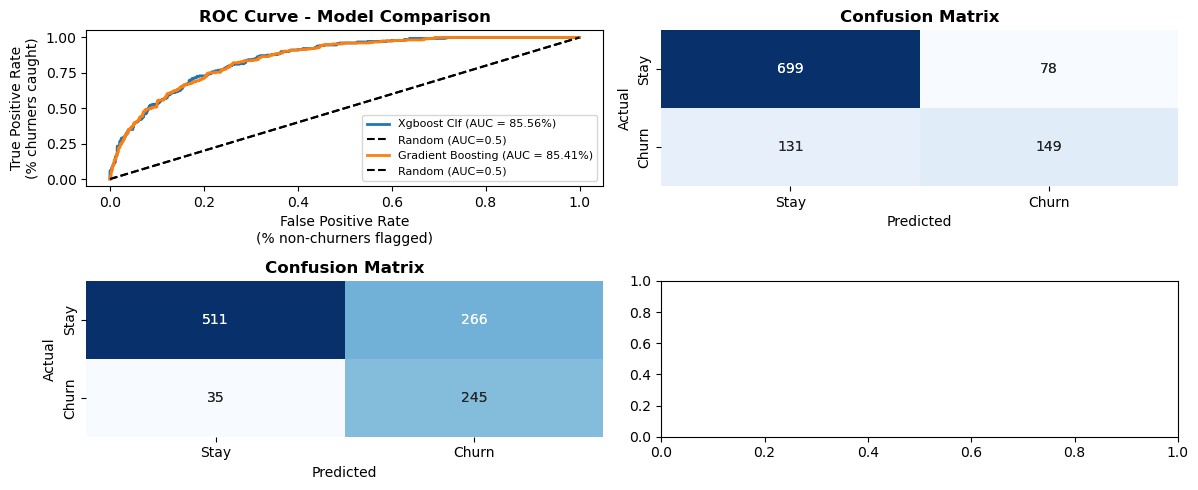

In [151]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 5))

for name, proba in [
    ('Xgboost Clf', y_proba_xg),
    ('Gradient Boosting', y_proba_gb)
]:
  fpr, tpr, _ = roc_curve(y_test, proba)
  auc = roc_auc_score(y_test, proba)
  axes[0, 0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.2%})")

  axes[0, 0].plot([0, 1], [0,1], 'k--', label='Random (AUC=0.5)')
  axes[0, 0].set_xlabel('False Positive Rate\n(% non-churners flagged)')
  axes[0, 0].set_ylabel('True Positive Rate\n(% churners caught)')
  axes[0, 0].set_title('ROC Curve - Model Comparison', fontweight='bold')
  axes[0, 0].legend(fontsize=8)

  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Stay', 'Churn'], yticklabels=['Stay','Churn'], ax=axes[0,1])
  axes[0,1].set_xlabel('Predicted')
  axes[0,1].set_ylabel('Actual')
  axes[0,1].set_title('Confusion Matrix', fontweight='bold')

  sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
              xticklabels=['Stay', 'Churn'], yticklabels=['Stay','Churn'], ax=axes[1, 0])
  axes[1, 0].set_xlabel('Predicted')
  axes[1, 0].set_ylabel('Actual')
  axes[1, 0].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

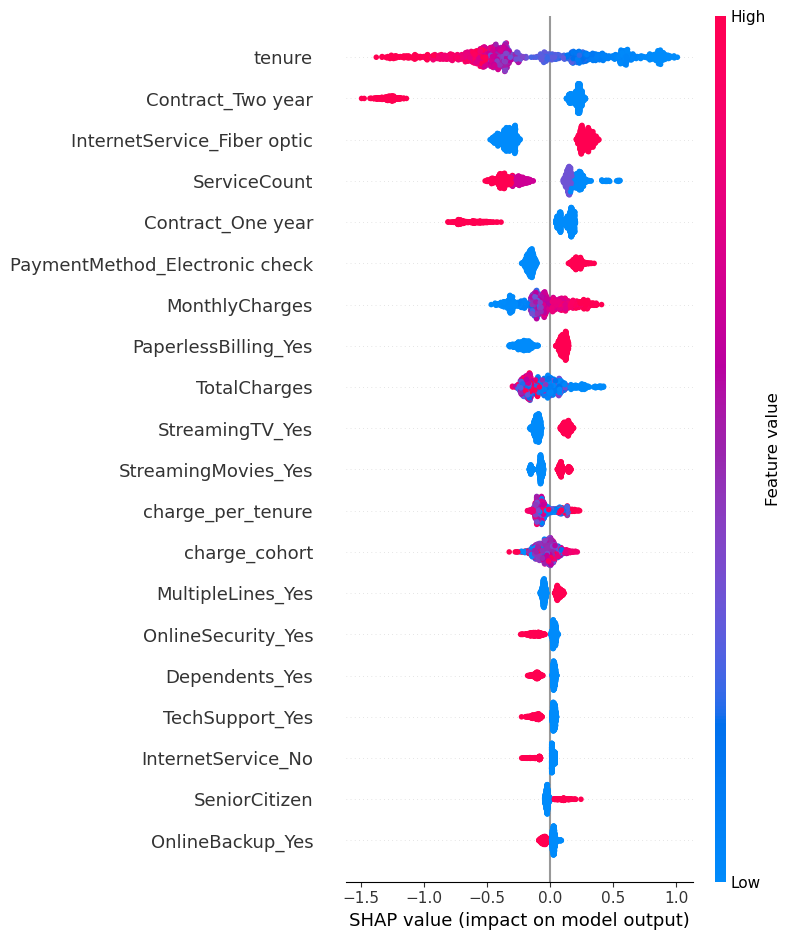

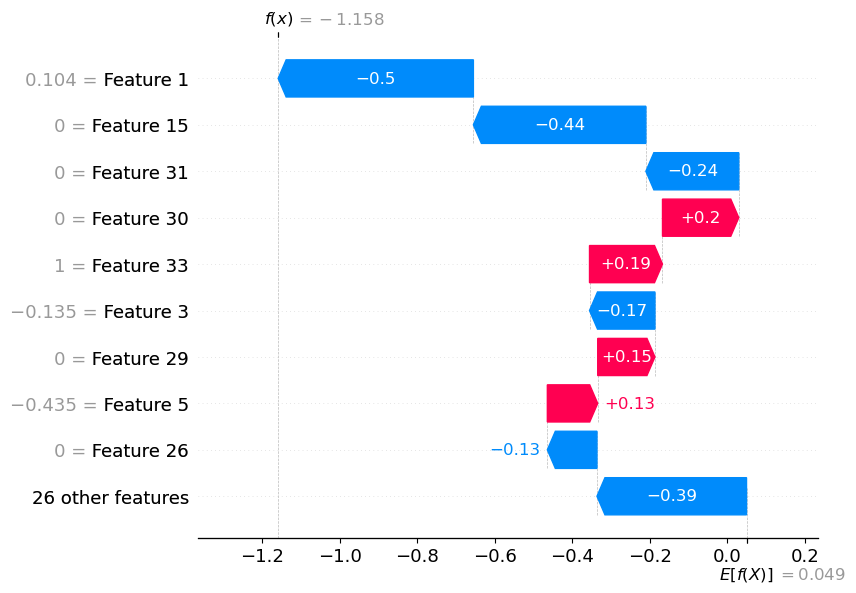

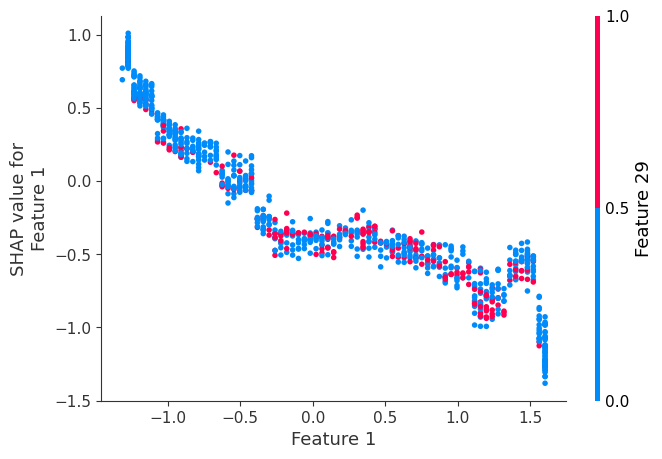

In [153]:
import shap

xgb_clf  = best_model.named_steps["clf"]
X_t_proc = best_model.named_steps["pipe"].transform(X_test)

explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_t_proc)

# 1. Global feature importance (beeswarm)
shap.summary_plot(shap_values, X_t_proc,
    feature_names=feat_name)

# 2. Single-customer explanation (for agents)
shap.waterfall_plot(shap_values[42])

# 3. SHAP interaction values
shap.dependence_plot(
    "Feature 1", shap_values.values, X_t_proc,
    interaction_index="Feature 29"
)

In [157]:
new_customer = pd.DataFrame([{
    'tenure':          2,
    'MonthlyCharges':  19.0,
    'TotalCharges':    178.0,
    'SeniorCitizen':   0,
    'Contract':        'Month-to-month',
    'InternetService': 'Fiber optic',
    'PaymentMethod':   'Electronic check',
    'OnlineSecurity':  'No',
    'TechSupport':     'No',
    'PaperlessBilling':'Yes',
    'gender': 'Male',
    'Partner': 'No',
    'Dependents':'Yes',
    'PhoneService': 'No',
    'MultipleLines': 'Yes',
    'OnlineBackup': 'No',
    'DeviceProtection' : 'Yes',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No'

}])

prob = best_model.predict_proba(new_customer)[0][1]
predicted = best_model.predict(new_customer)
print(f"\nChurn probability: {prob:.1%}")
print(f"Churn Predicted: {predicted}")
print(f"Risk level: {'🔴 HIGH' if prob > 0.6 else '🟡 MEDIUM' if prob > 0.3 else '🟢 LOW'}")
print(new_customer)


Churn probability: 81.0%
Churn Predicted: [1]
Risk level: 🔴 HIGH
   tenure  MonthlyCharges  TotalCharges  SeniorCitizen        Contract  \
0       2            19.0         178.0              0  Month-to-month   

  InternetService     PaymentMethod OnlineSecurity TechSupport  \
0     Fiber optic  Electronic check             No          No   

  PaperlessBilling gender Partner Dependents PhoneService MultipleLines  \
0              Yes   Male      No        Yes           No           Yes   

  OnlineBackup DeviceProtection StreamingTV StreamingMovies  
0           No              Yes         Yes              No  


In [159]:
y_proba = best_model_gb.predict_proba(X_test)[:, 1]
pred_test =best_model_gb.predict(X_test)

prob = best_model_gb.predict_proba(new_customer)[0][1]
predicted = best_model_gb.predict(new_customer)
print(f"\nChurn probability: {prob:.1%}")
print(f"Churn Predicted: {predicted}")
print(f"Risk level: {'🔴 HIGH' if prob > 0.6 else '🟡 MEDIUM' if prob > 0.3 else '🟢 LOW'}")
print(new_customer)


Churn probability: 53.4%
Churn Predicted: [1]
Risk level: 🟡 MEDIUM
   tenure  MonthlyCharges  TotalCharges  SeniorCitizen        Contract  \
0       2            19.0         178.0              0  Month-to-month   

  InternetService     PaymentMethod OnlineSecurity TechSupport  \
0     Fiber optic  Electronic check             No          No   

  PaperlessBilling gender Partner Dependents PhoneService MultipleLines  \
0              Yes   Male      No        Yes           No           Yes   

  OnlineBackup DeviceProtection StreamingTV StreamingMovies  
0           No              Yes         Yes              No  
